# Tutorial: Milestone 2 - Real MIntRec Multimodal Fusion

Audience:
- You've completed the toy fusion notebook (`milestone2_toy_fusion.ipynb`) and understand concatenation
  fusion, StandardScaler, and why an ablation matters. This notebook runs the same idea on REAL data.

Prerequisites:
- Run these once first, in order (each is a real download/compute step, not instant):
  `python src/generate_mintrec_multimodal.py`, then `python src/extract_mintrec_embeddings.py`.

Learning goals:
- By the end, you can explain what a frozen pretrained encoder embedding is, and read a real
  (not engineered) result comparing text-only vs. fused accuracy on real dialogue.
- You can also run two cheap sweeps to tell apart the two usual suspects when a wide fused feature
  vector underperforms: overfitting, versus one feature block numerically drowning out another.

**What changed from the toy notebook:** real short video clips (real dialogue from the Superstore TV
show, from the MIntRec dataset) instead of invented sine waves and solid colors; real frozen
`wav2vec2-base` (audio) and `ResNet18` (video) embeddings instead of hand-written FFT/color-stat
features; 20 real, imbalanced intent classes instead of 8 tidy invented ones. The concatenation +
scaling + Logistic Regression structure is otherwise the same.


## Outline

1. Setup
2. Step 1 - Load the real MIntRec multimodal index
3. Step 2 - Split into train / validation / test
4. Step 3 - Load precomputed real embeddings and fuse them
5. Step 4 - Evaluate, and compare against Milestone 0
6. Ablation - does scaling help on real data? does fusion help?
7. Diagnose it - overfitting, or one block drowning out another?
8. Look at the mistakes
9. Exercises
10. Pitfalls and extensions


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
INDEX_PATH = PROJECT_ROOT / "data" / "mintrec_multimodal" / "index.csv"
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "mintrec_multimodal" / "embeddings"
RESULTS_DIR = PROJECT_ROOT / "results"
INDEX_PATH


WindowsPath('C:/Users/dbest/Downloads/multimodal-intent-inference/multimodal-intent-inference/data/mintrec_multimodal/index.csv')

## Step 1 - Load the real MIntRec multimodal index

Unlike the toy version, this data is real dialogue: 20 real intent classes, genuinely imbalanced,
with real `season`/`episode`/`clip` provenance for every row.


In [2]:
df = pd.read_csv(INDEX_PATH)
print(f"Loaded {len(df)} samples from {INDEX_PATH.name}")
print(f"Number of distinct intent classes: {df['intent'].nunique()}")
df["intent"].value_counts()


Loaded 300 samples from index.csv
Number of distinct intent classes: 20


intent
Advise          15
Agree           15
Apologise       15
Arrange         15
Ask for help    15
Care            15
Comfort         15
Complain        15
Criticize       15
Flaunt          15
Greet           15
Inform          15
Introduce       15
Joke            15
Leave           15
Oppose          15
Praise          15
Prevent         15
Taunt           15
Thank           15
Name: count, dtype: int64

Sample: 'okay, well, how about weekends off?' -> intent=Advise
From: S05 E13 clip 498


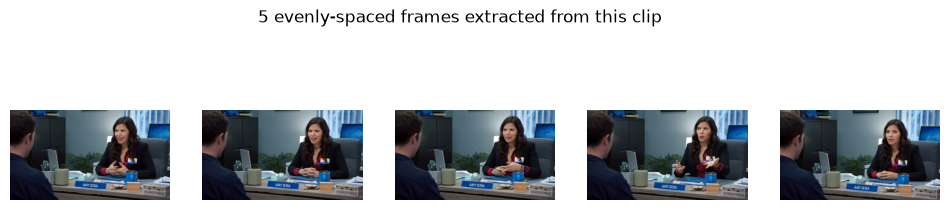

In [3]:
# A real sample: its text, its actual clip location, and its extracted frames.
sample = df.iloc[0]
print(f"Sample: {sample['text']!r} -> intent={sample['intent']}")
print(f"From: {sample['season']} {sample['episode']} clip {sample['clip']}")

frame_paths = sorted((PROJECT_ROOT / sample["frame_dir"]).glob("frame_*.jpg"))
fig, axes = plt.subplots(1, len(frame_paths), figsize=(12, 3))
for ax, fp in zip(axes, frame_paths):
    ax.imshow(plt.imread(fp))
    ax.axis("off")
fig.suptitle("5 evenly-spaced frames extracted from this clip")
plt.show()


## Step 2 - Split into train / validation / test

Identical split logic to every prior notebook.


In [4]:
train_val, test = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["intent"]
)
train, val = train_test_split(
    train_val, test_size=0.1875, random_state=42, stratify=train_val["intent"]
)

print(f"train: {len(train)} samples")
print(f"val:   {len(val)} samples")
print(f"test:  {len(test)} samples")


train: 195 samples
val:   45 samples
test:  60 samples


## Step 3 - Load precomputed real embeddings and fuse them

`src/extract_mintrec_embeddings.py` already ran `wav2vec2-base` and `ResNet18` over every clip and
cached the results. We just load those cached numbers here -- no neural network runs in this notebook,
which is why it stays fast even though real encoders were involved upstream.


In [5]:
def build_audio_features(frame_df):
    return np.array([np.load(EMBEDDINGS_DIR / f"{sid}.npz")["audio"] for sid in frame_df["sample_id"]])


def build_video_features(frame_df):
    return np.array([np.load(EMBEDDINGS_DIR / f"{sid}.npz")["video"] for sid in frame_df["sample_id"]])


def build_features(frame_df, tfidf, fit):
    text_feats = tfidf.fit_transform(frame_df["text"]).toarray() if fit else tfidf.transform(frame_df["text"]).toarray()
    return text_feats, build_audio_features(frame_df), build_video_features(frame_df)


In [6]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
text_train, audio_train, video_train = build_features(train, tfidf, fit=True)
fused_train_raw = np.hstack([text_train, audio_train, video_train])
print(f"Fused feature vector size: {fused_train_raw.shape[1]} "
      f"(text={text_train.shape[1]}, audio=768, video=512)")

scaler = StandardScaler()
fused_train = scaler.fit_transform(fused_train_raw)

clf = LogisticRegression(max_iter=1000)
clf.fit(fused_train, train["intent"])
print("Training done.")


Fused feature vector size: 2706 (text=1426, audio=768, video=512)
Training done.


## Step 4 - Evaluate, and compare against Milestone 0

Fusion scores 0.117 accuracy here -- well below the 0.383 that this same pipeline gets from text
alone, on the identical 60-row test set (see the ablation further down). That is a real result, not a
bug, but the reason for it is worth getting right, because the obvious explanation is the wrong one.

**It is not "too many dimensions for too few rows."** The fused vector is 2,706 numbers wide and
there are only 195 training rows, which certainly *looks* like a textbook overfitting setup. Two
pieces of evidence say it isn't. First, the regularization sweep below holds flat at 0.10-0.117 all
the way from `C=0.001` (very strong regularization) to `C=10` (very weak) -- if the model were
overfitting, reining it in that hard would win back a meaningful chunk of the lost accuracy, and it
wins back nothing. Second, text alone has *more* dimensions (1,426) than audio and video combined
(1,280), against those same 195 rows, and it scores 0.383 -- and gets *better* with weaker
regularization, the exact opposite of what overfitting predicts.

**What is actually happening is a scale imbalance between the blocks.** Before any scaling, the three
feature blocks live on completely different number scales: TF-IDF text values average about 0.002 in
size, wav2vec2 audio values about 0.18, and ResNet18 video values about 0.86 -- roughly 400x bigger
than text. When `np.hstack` glues them together, Logistic Regression is looking at 1,280 large, dense,
always-nonzero audio/video numbers sitting next to 1,426 tiny, mostly-zero text numbers, and it fits
the loud block.

That is what "a dense block crowds out a sparse block" means in practice. Every audio/video dimension
moves on every single example, so each one earns weight easily; a TF-IDF dimension is zero for almost
every sentence and only speaks up when its particular word appears. Under one shared L2 penalty --
one budget for all 2,706 weights -- the model spends that budget where it gets cheap movement, and
the text features barely get a vote.

`StandardScaler` helps a little (0.117 with it vs. 0.067 without) because it puts every *column* on
equal variance. But it does nothing about *block* imbalance: 1,280 dense unit-variance dimensions
still outvote 1,426 sparse near-binary ones. The giveaway is where fused lands -- 0.117 is right at
the audio/video-only level (0.067 and 0.083), not somewhere between text-only and audio/video-only.
The dense blocks aren't diluting text, they're replacing it. The block down-weighting sweep below
shows this directly: turn the audio/video block's volume down and accuracy climbs straight back to
the text-only 0.383.

**One honest caveat on the single-modality numbers.** Audio-only (0.067) and video-only (0.083) both
sit above the 1/20 = 0.05 chance line, and it is tempting to say they "carry real signal." On 60 test
rows they don't earn that claim: those are 4 and 5 correct predictions against a chance expectation of
3, and a one-sided binomial test against chance gives p = 0.35 for audio and p = 0.18 for video.
Neither is distinguishable from guessing. That is a useful lesson rather than a disappointing one --
with 3 test samples per class, this experiment simply cannot resolve a small effect either way. If you
want to know whether frozen audio/video embeddings carry usable intent signal, the answer is more
data, not a more confident sentence.

In [7]:
text_test, audio_test, video_test = build_features(test, tfidf, fit=False)
fused_test = scaler.transform(np.hstack([text_test, audio_test, video_test]))
preds = clf.predict(fused_test)
truth = test["intent"].tolist()

acc = accuracy_score(truth, preds)
macro_f1 = f1_score(truth, preds, average="macro")
print(f"Accuracy : {acc:.3f}")
print(f"Macro-F1 : {macro_f1:.3f}")


Accuracy : 0.117
Macro-F1 : 0.096


In [8]:
print(classification_report(truth, preds, zero_division=0))


              precision    recall  f1-score   support

      Advise       0.00      0.00      0.00         3
       Agree       0.08      0.33      0.13         3
   Apologise       0.33      0.33      0.33         3
     Arrange       0.00      0.00      0.00         3
Ask for help       0.00      0.00      0.00         3
        Care       0.00      0.00      0.00         3
     Comfort       0.00      0.00      0.00         3
    Complain       0.00      0.00      0.00         3
   Criticize       0.00      0.00      0.00         3
      Flaunt       0.25      0.33      0.29         3
       Greet       0.25      0.67      0.36         3
      Inform       0.00      0.00      0.00         3
   Introduce       0.50      0.33      0.40         3
        Joke       0.00      0.00      0.00         3
       Leave       0.00      0.00      0.00         3
      Oppose       0.50      0.33      0.40         3
      Praise       0.00      0.00      0.00         3
     Prevent       0.00    

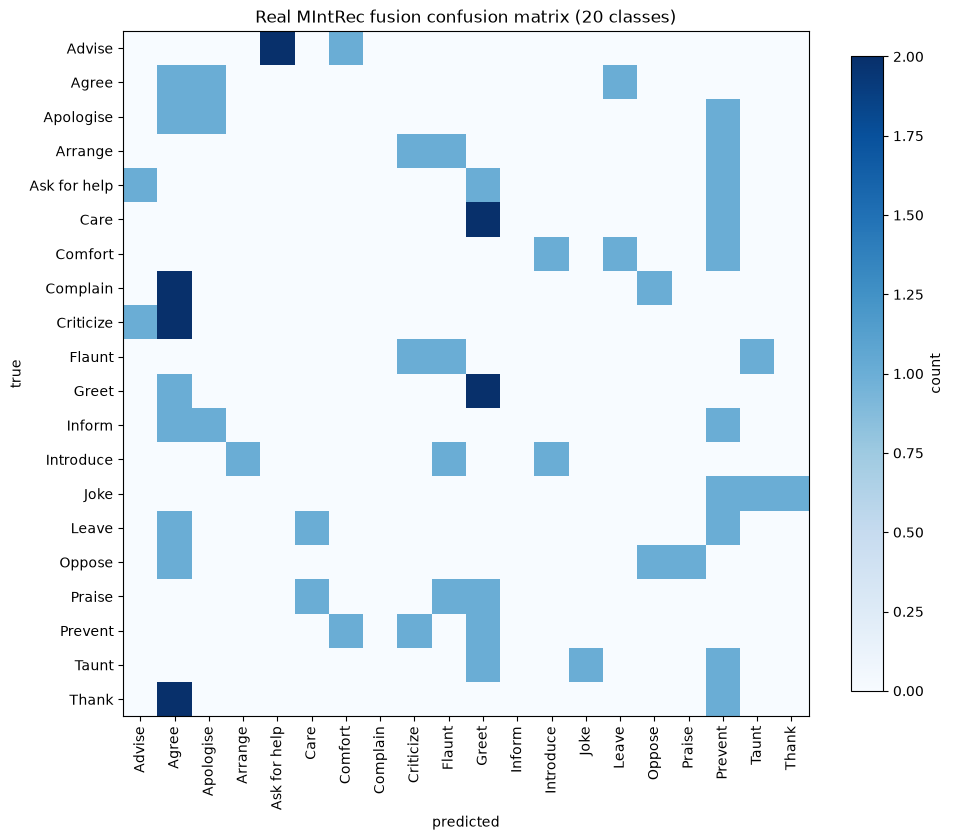

In [9]:
labels = sorted(test["intent"].unique())
cm = confusion_matrix(truth, preds, labels=labels)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=90)
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Real MIntRec fusion confusion matrix (20 classes)")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()


### Compare against Milestone 0 and the toy fusion notebook

The first three rows are useful context but they're different experiments -- different data, different
class counts, different sizes. The fourth row is the only apples-to-apples comparison: text alone, on
these exact 300 clips and this exact split. That is the number fusion has to beat, and doesn't.


In [10]:
# The other three rows are reference points from different data. The one truly like-for-like
# comparison is text alone on THIS notebook's 300 clips and THIS split, so compute it here.
text_only_clf = LogisticRegression(max_iter=1000).fit(text_train, train["intent"])
text_only_preds = text_only_clf.predict(text_test)
text_only_acc = accuracy_score(truth, text_only_preds)
text_only_f1 = f1_score(truth, text_only_preds, average="macro")

comparison = pd.DataFrame([
    {"model": "Text-only, toy 8-class (M0)", "accuracy": 0.550, "macro_f1": 0.521},
    {"model": "Text-only, real 20-class, 2224 rows (M1)", "accuracy": 0.508, "macro_f1": 0.409},
    {"model": "Fused, toy 8-class, synthetic (M2 toy)", "accuracy": 0.700, "macro_f1": 0.683},
    {"model": "Text-only, same 300 clips + split (M2 real)", "accuracy": text_only_acc, "macro_f1": text_only_f1},
    {"model": "Fused, real 20-class, real encoders (M2 real)", "accuracy": acc, "macro_f1": macro_f1},
]).set_index("model")
comparison


,accuracy,macro_f1
model,,
"Text-only, toy 8-class (M0)",0.550000,0.521000
"Text-only, real 20-class, 2224 rows (M1)",0.508000,0.409000
"Fused, toy 8-class, synthetic (M2 toy)",0.700000,0.683000
"Text-only, same 300 clips + split (M2 real)",0.383333,0.347302
"Fused, real 20-class, real encoders (M2 real)",0.116667,0.095801


## Ablation - does scaling help on real data? does fusion help?

The toy notebook found `StandardScaler` measurably *hurt* accuracy there -- but that was because one
toy modality (video) was artificially made almost perfectly separable. Real audio/video embeddings
won't have that property, so this needs checking again here rather than assumed either way.

These rows also do double duty. Where the fused number lands *relative to* text-only and to
audio/video-only is the main clue for the diagnosis in the next section, so read them as a set rather
than one line at a time.


In [11]:
def evaluate_config(name, train_feats, test_feats, train_labels, test_labels, use_scaler, C=1.0):
    if use_scaler:
        s = StandardScaler()
        train_feats = s.fit_transform(train_feats)
        test_feats = s.transform(test_feats)
    c = LogisticRegression(max_iter=1000, C=C)  # C is the regularization dial: smaller = stronger
    c.fit(train_feats, train_labels)
    p = c.predict(test_feats)
    a = accuracy_score(test_labels, p)
    f = f1_score(test_labels, p, average="macro")
    print(f"{name:35s} accuracy={a:.3f}  macro-F1={f:.3f}")
    return a, f


fused_test_raw = np.hstack([text_test, audio_test, video_test])
train_labels, test_labels = train["intent"], test["intent"]

evaluate_config("text-only, no scaler", text_train, text_test, train_labels, test_labels, False)
evaluate_config("text-only, with scaler", text_train, text_test, train_labels, test_labels, True)
evaluate_config("audio-only, with scaler", audio_train, audio_test, train_labels, test_labels, True)
evaluate_config("video-only, with scaler", video_train, video_test, train_labels, test_labels, True)
evaluate_config("fused, no scaler", fused_train_raw, fused_test_raw, train_labels, test_labels, False)
evaluate_config("fused, with scaler (ships)", fused_train_raw, fused_test_raw, train_labels, test_labels, True)


text-only, no scaler                accuracy=0.383  macro-F1=0.347
text-only, with scaler              accuracy=0.350  macro-F1=0.308
audio-only, with scaler             accuracy=0.067  macro-F1=0.043
video-only, with scaler             accuracy=0.083  macro-F1=0.098


fused, no scaler                    accuracy=0.067  macro-F1=0.071
fused, with scaler (ships)          accuracy=0.117  macro-F1=0.096


(0.11666666666666667, 0.0958008658008658)

### Diagnose it: overfitting, or one block drowning out another?

Fusion lost badly. Two explanations are on the table, and they make opposite predictions, so one cell
of evidence each settles it.

- **Overfitting** (2,706 dimensions, 195 training rows): then turning regularization *up* -- smaller
  `C` in `LogisticRegression` -- should win back a good share of the lost accuracy.
- **Scale dominance** (the audio/video block is numerically louder than the text block): then simply
  turning that block's volume down before concatenating should walk accuracy back toward text-only,
  with no change to regularization at all.

Run both sweeps and see which prediction the data actually keeps.


In [12]:
# The premise: how big are these numbers before any scaling touches them?
for block_name, block in [("text ", text_train), ("audio", audio_train), ("video", video_train)]:
    print(f"{block_name} mean |value| = {np.abs(block).mean():.4f}")

# Test 1 - overfitting? If so, stronger regularization (smaller C) should recover accuracy.
print("\nregularization sweep, fused + StandardScaler:")
for C in [0.001, 0.01, 0.1, 1.0, 10.0]:
    evaluate_config(f"  fused+scaled, C={C}", fused_train_raw, fused_test_raw,
                    train_labels, test_labels, True, C=C)

# Test 2 - scale dominance? Shrink ONLY the audio+video block before gluing it to untouched
# text, and use no StandardScaler, so the single thing changing is how loud that block is.
av_train = np.hstack([audio_train, video_train])
av_test = np.hstack([audio_test, video_test])
print("\naudio+video block turned down, text untouched, no scaler:")
for w in [1.0, 0.5, 0.1, 0.01, 0.0]:
    evaluate_config(f"  audio/video x {w}", np.hstack([text_train, av_train * w]),
                    np.hstack([text_test, av_test * w]), train_labels, test_labels, False)


text  mean |value| = 0.0022
audio mean |value| = 0.1783
video mean |value| = 0.8566

regularization sweep, fused + StandardScaler:


  fused+scaled, C=0.001             accuracy=0.117  macro-F1=0.099


  fused+scaled, C=0.01              accuracy=0.100  macro-F1=0.082


  fused+scaled, C=0.1               accuracy=0.100  macro-F1=0.080


  fused+scaled, C=1.0               accuracy=0.117  macro-F1=0.096
  fused+scaled, C=10.0              accuracy=0.117  macro-F1=0.090

audio+video block turned down, text untouched, no scaler:


  audio/video x 1.0                 accuracy=0.067  macro-F1=0.071


  audio/video x 0.5                 accuracy=0.083  macro-F1=0.096
  audio/video x 0.1                 accuracy=0.217  macro-F1=0.205
  audio/video x 0.01                accuracy=0.383  macro-F1=0.343


  audio/video x 0.0                 accuracy=0.383  macro-F1=0.347


**Reading the two sweeps.** The regularization sweep is flat -- 0.10 to 0.117 across four orders of
magnitude of `C`. Regularization is not the lever here, so overfitting is not the disease. The
down-weighting sweep is the opposite: a clean, monotone climb as the audio/video block gets quieter,
1.0 -> 0.067, 0.5 -> 0.083, 0.1 -> 0.217, 0.01 -> 0.383, and 0.0 (text alone) -> 0.383. Nothing about
the model changed across those five runs except how loudly one block gets to speak, and that alone
accounts for the entire gap.

Note also where the weight=1.0 row sits: 0.067, the same as audio-only. Fusion at full volume isn't
blending text with audio/video -- it's throwing text away. That is the concrete meaning of a dense
block crowding out a sparse one.


## Look at the mistakes


In [13]:
results_df = pd.DataFrame({"text": test["text"], "true": truth, "predicted": preds})

RESULTS_DIR.mkdir(exist_ok=True)
out_path = RESULTS_DIR / "mintrec_multimodal_predictions.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved every test prediction to {out_path.relative_to(PROJECT_ROOT)}")

mistakes = results_df[results_df["true"] != results_df["predicted"]]
print(f"\n{len(mistakes)} of {len(results_df)} test sentences were misclassified "
      f"({len(mistakes)/len(results_df):.1%}).")
mistakes.head(10)


Saved every test prediction to results\mintrec_multimodal_predictions.csv

53 of 60 test sentences were misclassified (88.3%).


,text,true,predicted
130,that guy's always making up stuff about people.,Criticize,Agree
22,"oh, yeah, sure.",Agree,Leave
141,my official ordination license,Flaunt,Criticize
240,that's good advice.,Praise,Flaunt
179,"in fact, you are expected to carry them.",Inform,Agree
61,"glenn, can i borrow $2,000 for sales tax?",Ask for help,Prevent
259,"uh, don't eat the baby food. the baby food is ...",Prevent,Greet
216,i am going to sit in traffic for 45 minutes an...,Leave,Prevent
124,but really you were only using me to get to bo!,Criticize,Advise
49,"so glenn, you're gonna be running care package...",Arrange,Flaunt


## Exercises

1. Compare this notebook's confusion matrix to Milestone 1's text-only 20-class confusion matrix
   (`notebooks/milestone1_mintrec_text.ipynb`). Are the same intent pairs confused (e.g. `Complain` vs.
   `Criticize`), or did adding audio/video change which mistakes the model makes?
2. Extend the down-weighting sweep. It shrinks audio and video together -- shrink them one at a time
   instead (audio x 0.01 with video left alone, then video x 0.01 with audio left alone). Which block
   does more of the damage, and does that match the raw `mean |value|` numbers printed at the top of
   that cell? Then try the mirror image: leave audio/video alone and multiply the *text* block up by
   100x. Predict the result before you run it -- if the story is really about relative loudness
   between blocks, both directions should land in the same place.
3. `src/generate_mintrec_multimodal.py --full` would use all 2,213 available clips instead of this
   notebook's 300-clip subset. Without running it (it's a ~2.3GB download, needing its own
   confirmation), predict: with ~7x more training data per class, which of these two numbers moves
   more -- text-only 0.383, or fused 0.117? Given what the sweeps showed about *why* fused is low,
   would you expect more data to close that gap on its own?


## Pitfalls and extensions

**Common mistake:** assuming a result from synthetic/toy data transfers to real data. The toy
notebook's "scaling hurts" finding didn't necessarily hold here -- see the ablation above for what
actually happened on real embeddings. Always re-check assumptions when the underlying data changes.

**Common mistake:** trusting `StandardScaler` to make concatenation fusion fair. It equalizes each
*column's* variance, not each *block's* total influence. A 1,280-dimension dense embedding block and a
1,426-dimension sparse TF-IDF block can both be perfectly standardized and still not get an equal say,
because they differ in how many of their dimensions actually move on a given example. Whenever you
concatenate blocks from different sources, check the fused result against each block alone: if fusion
lands at the *weak* block's accuracy instead of somewhere between the two, the strong block is
crowding the other out rather than adding to it.

**Common mistake:** reaching for "curse of dimensionality" whenever a wide feature vector performs
badly. It's a real phenomenon, but it's also the easiest story to tell, so it gets blamed for results
it didn't cause. The check is cheap and takes one loop: sweep `C`. If regularization doesn't move the
number, the problem isn't too much statistical freedom, and you need a different hypothesis.

**Extension:** the down-weighting sweep is a crude version of a real technique. Production multimodal
systems handle block imbalance properly -- per-block normalization, per-block regularization
strengths, learned gating that decides how much each modality contributes per example, or projecting
every modality to a shared dimensionality first so no block wins on width alone.

**Extension:** this pipeline uses a 300-clip stratified subset for speed. Once you're ready to commit
to a larger download and longer processing time, `--full` on both
`src/generate_mintrec_multimodal.py` and a rerun of `src/extract_mintrec_embeddings.py` would use all
2,213 available real clips -- confirm the ~2.3GB download and the longer embedding-extraction run with
Claude Code first, per this project's rules.

**Extension:** both encoders are frozen here (no fine-tuning), per `CLAUDE.md`'s preference while
prototyping. A natural next step once this pipeline is trusted: fine-tune just the classifier head
further, or unfreeze the last layer or two of one encoder, and compare.
